# Transient Universe

Model to use:

$ f(x) = \begin{cases} b & \text{if } t < 0 \\ b + A\exp{-\alpha(t-t_0)} & \text{if } t \geq t_0 \end{cases} $

Priors:

$b \in \text{Uniform} [0,50]$\
$t_0 \in \text{Uniform} [0,100]$\
$\ln(\alpha) \text{Uniform} [-5,5]$


First, read the data

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import sys 
sys.path.append(r"C:\Users\ricca\Documents\Unimib-Code\Astrostatistics\Notebooks")
from Utilities import plot_settings

In [2]:
data = np.load(r"C:\Users\ricca\Documents\Unimib-Code\AstroStatistics\Notebooks\Data\transient.npy")

In [3]:
time = data.T[0]
flux = data.T[1]
ferr = data.T[2]

In [4]:
import scipy

Exploring data

Text(0.5, 1.0, 'Raw data')

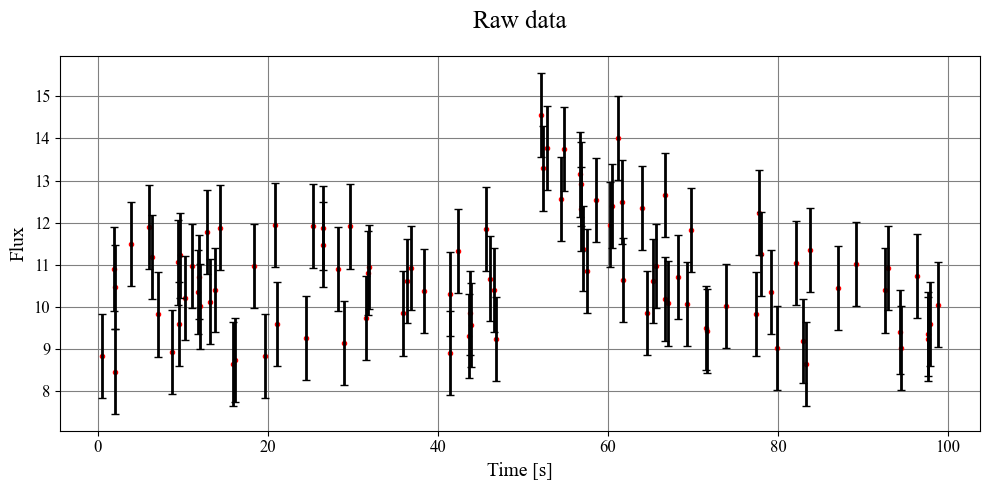

In [5]:
plt.errorbar(time, flux, ferr, fmt='.', color='red', linestyle='None', ecolor='black', capsize=3,barsabove=True)
plt.xlabel('Time [s]')
plt.ylabel('Flux')
plt.title('Raw data')

Text(0.5, 1.0, 'Flux error distribution')

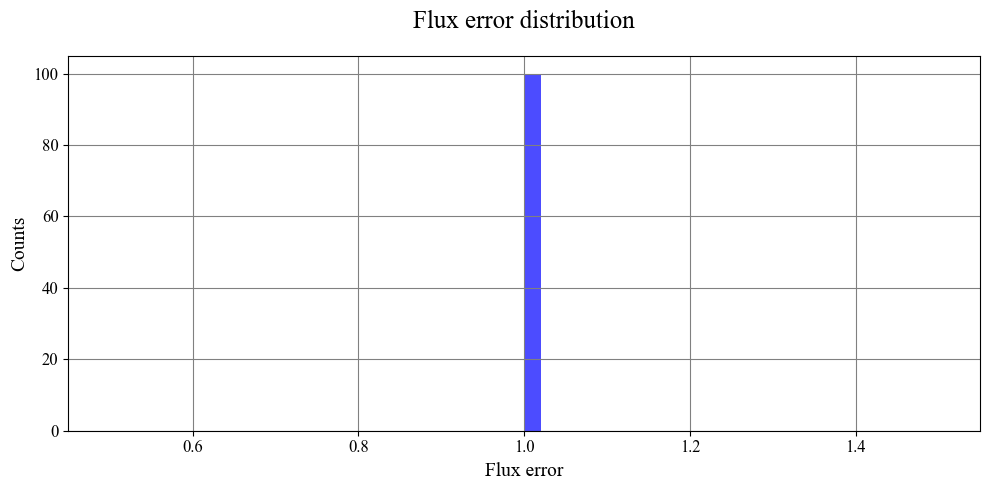

In [6]:
plt.hist(ferr, bins=50, color='blue', alpha=0.7);
plt.xlabel('Flux error')
plt.ylabel('Counts')
plt.title('Flux error distribution')

Measurement errors are homoscedastic! I can assume that the deviations between the observed values $\{y_i\}$ and the model predictions $f(\{x_i\}|\vec{\theta})$ at fixed values of $\{x_i\}$ are drawned from a Gaussian distribution with a constant scale parameter $\sigma$ .\
 This means that I can use the following likelihood:

$\mathcal{L} = \prod_{i=1}^{N} \mathcal{G}(f(x_i, \vec{\theta})|y_i, \sigma) = \prod_{i=1}^{N} \frac{1}{\sqrt{2\pi}\sigma} e^{-\frac{1}{2}\frac{(y_i - f(x_i|\vec{\theta}))^{2}}{\sigma^{2}}}$

1. **Using one of the MCMC sampler that we looked at in class (emcee, pymc), perform a Bayesian analysis that recovers an MCMC chain of posterior probability samples for the joint parameter space of $\{A, t_0,b,\alpha\}$.**

Define the model and initial parameters

In [7]:
def model(x):
    A, t0, alpha, b = x
    return np.where(time < t0, b, b + A * np.exp(-alpha * (time - t0)))

In [8]:
b_estimate = np.mean(flux[time < 40])
A_estimate = np.max(flux)-b_estimate
t0_estimate= time[np.argmax(flux)]
a = np.where(flux-b_estimate < A_estimate/np.e , time, flux)
alpha_estimate = 1/(a[a>t0_estimate][0]-t0_estimate)

In [68]:
x0 = np.array([A_estimate, t0_estimate, alpha_estimate, b_estimate])

In [69]:
x0_dict = dict(zip(['A', 't0', 'alpha', 'b'], x0))

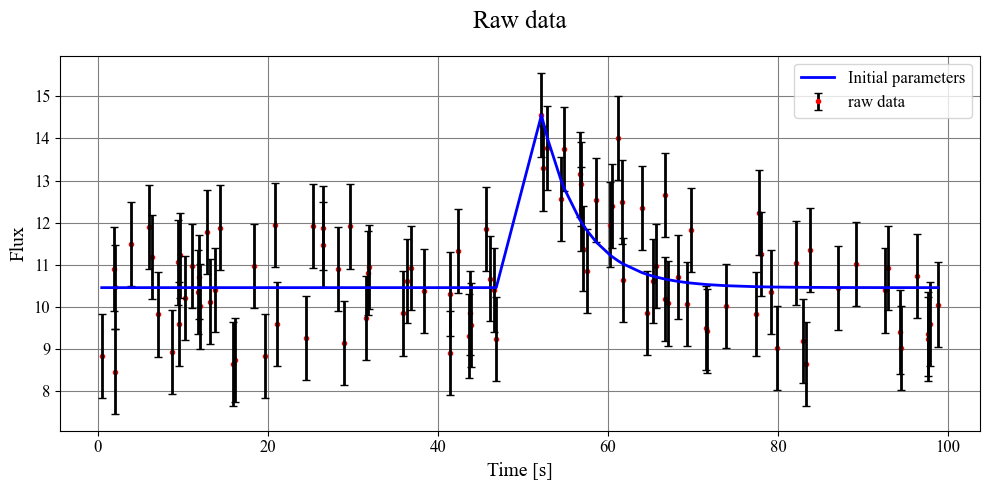

In [10]:
plt.errorbar(time, flux, ferr, fmt='.', color='red', linestyle='None', ecolor='black', capsize=3,barsabove=True, label='raw data')
plt.plot(time, model(x0), lw=2, color='blue', label='Initial parameters')
plt.xlabel('Time [s]')
plt.ylabel('Flux')
plt.title('Raw data')
plt.legend()

In [11]:
import pymc as pm

In [13]:
import pytensor.configdefaults as ptcfg

print("C++ compiler setting:", ptcfg.config.cxx)

C++ compiler setting: "C:\msys64\mingw64\bin\g++.EXE"


In [70]:
with pm.Model() as model:

    # Priors:
    A = pm.Uniform('A', lower=0, upper=50)
    b = pm.Uniform('b', lower=0, upper=50)
    alpha = pm.Uniform('alpha', lower=0, upper=100)
    t0 = pm.Uniform('t0', lower=0, upper=100)  # adjust bounds as needed
    
    # Expected transient signal model:
    mu = pm.math.switch(time < t0, b, b + A * pm.math.exp(-alpha * (time - t0)))

    # Likelihood assuming Gaussian errors:
    likelihood = pm.Normal('obs', mu=mu, sigma=ferr, observed=flux)

    # Sampling:
    trace = pm.sample(draws=1000, tune=500, chains=4, target_accept=0.99, initvals=x0_dict)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [A, b, alpha, t0]


Output()

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 899 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [71]:
import arviz as az

In [72]:
summary = az.summary(trace,
                     stat_focus="median",
                     hdi_prob=0.9,
                     kind="stats"
                     )

print(summary)

       median    mad  eti_5%  eti_95%
A       5.045  1.905   2.079    8.367
b      10.557  0.006  10.231   10.562
alpha   0.184  0.032   0.136    0.217
t0     36.662  5.918  29.626   51.862


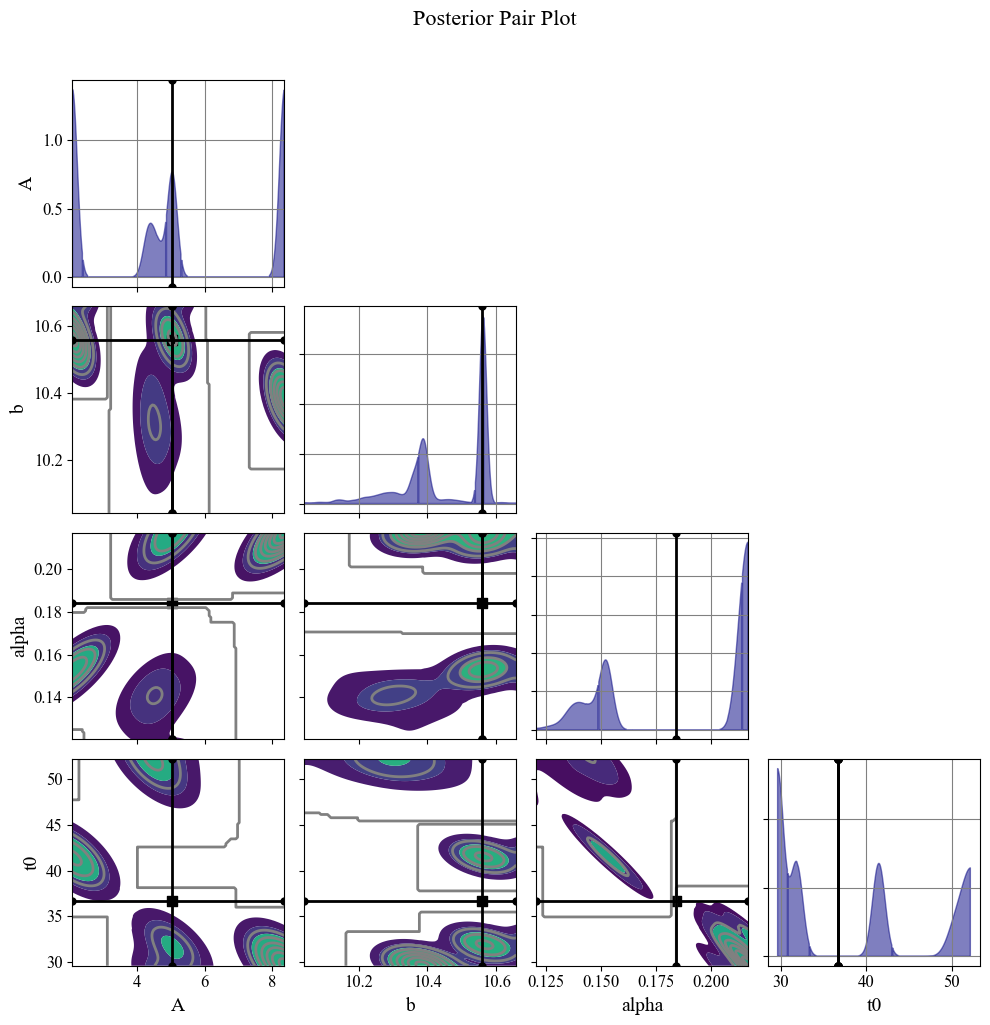

In [73]:
# Plot KDE pair plot with marginal histograms
az.plot_pair(
    trace,
    kind="kde",
    divergences=False,
    colorbar=True,
    marginals=True,
    point_estimate="median",         
    figsize=(10, 10),
    textsize=12,
    point_estimate_kwargs={'color': 'black', 'marker': 'o', 'markersize': 5},
    marginal_kwargs={'quantiles': [.25, .5, .75], 'contour': True, 
                     'fill_kwargs': {'alpha': 0.5},
                     'plot_kwargs': {'color': 'navy', 'linewidth': 2}},
    kde_kwargs={'contour': True, 'fill_kwargs': {'alpha': 0.5, 'linestyle': 'solid'}}
)

plt.suptitle("Posterior Pair Plot", fontsize=16, y=1.02)
plt.tight_layout()